In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Helpers
# -----------------------------
def load_attributions(pkl_path):
    with open(pkl_path, "rb") as f:
        A = pickle.load(f)   # Expect numpy array or torch tensor
    if not isinstance(A, np.ndarray):
        import torch
        if isinstance(A, torch.Tensor):
            A = A.cpu().numpy()
        else:
            raise ValueError(f"Unsupported data type in {pkl_path}: {type(A)}")
    return A

def compute_gini(x):
    """Compute Gini coefficient of a nonnegative 1D array"""
    x = np.abs(x.flatten()) + 1e-12
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return gini

def lorenz_curve(x):
    """Return Lorenz curve coordinates (cumulative population, cumulative attribution)."""
    x = np.abs(x.flatten()) + 1e-12
    x = np.sort(x)
    cumx = np.cumsum(x)
    cumx = cumx / cumx[-1]
    n = len(x)
    cum_pop = np.arange(1, n + 1) / n
    return cum_pop, cumx

def topk_mass(x, k=10):
    """Fraction of total attribution mass in top-k percent entries."""
    x = np.abs(x.flatten()) + 1e-12
    n = len(x)
    k_count = max(1, int(n * k / 100))
    top_mass = np.sum(np.sort(x)[-k_count:]) / np.sum(x)
    return top_mass




def attribution_entropy(x):
    """Compute entropy of normalized |A| values."""
    x = np.abs(x.flatten()) + 1e-12
    p = x / np.sum(x)
    H = -np.sum(p * np.log(p))
    return H

def cumulative_topk(x, ks=[1, 2, 5, 10, 20, 50]):
    """Return fraction of total mass in top-k% entries for a list of ks."""
    x = np.abs(x.flatten()) + 1e-12
    x_sorted = np.sort(x)[::-1]
    n = len(x)
    cum_masses = []
    for k in ks:
        k_count = max(1, int(n * k / 100))
        mass = np.sum(x_sorted[:k_count]) / np.sum(x_sorted)
        cum_masses.append(mass)
    return cum_masses

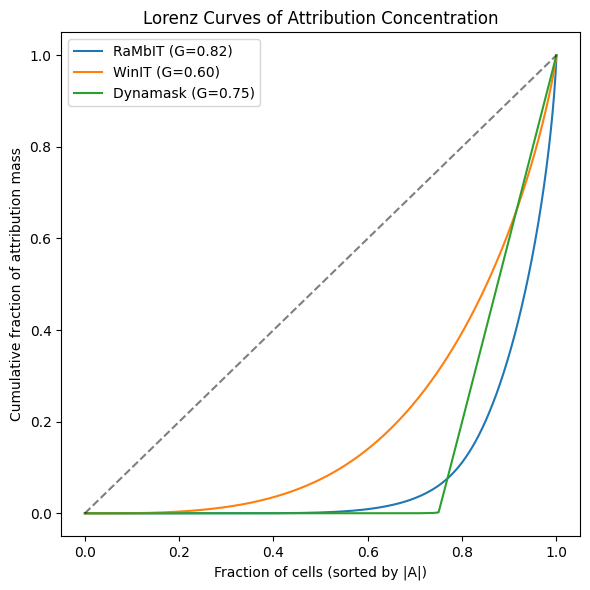

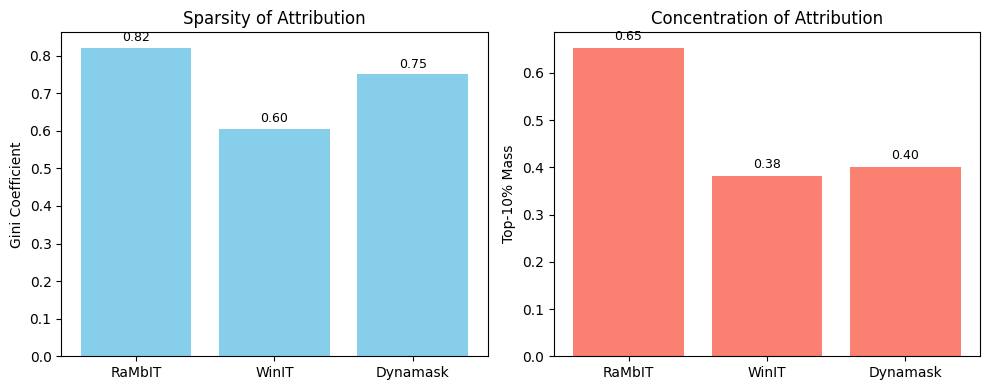

=== Results ===
RaMbIT     | Gini=0.821 | Top-10%=0.653
WinIT      | Gini=0.605 | Top-10%=0.382
Dynamask   | Gini=0.750 | Top-10%=0.400


In [22]:
# dataset_name = 'simulated_state'
dataset_name = 'simulated_switch'
# Example: paths to your attribution pickle files
method_files = {
    "RaMbIT": f"../output/gru1layer/{dataset_name}/jimex_num_masks_5_window_size_10_num_samples_3_wt_bounds_1_4_pd_usedatadist_test_importance_scores_0.pkl",
    # "WinIT": f"../output/gru1layer/{dataset_name}/winit_window_10_pd_usedatadist_test_importance_scores_0.pkl",
    "WinIT": f"../output/gru1layer/{dataset_name}/winit_window_10_samples_3_pd_usedatadist_test_importance_scores_0.pkl",
    "Dynamask": f"../output/gru1layer/{dataset_name}/dynamask_gaussian_timereg_1_sizereg_100_area_0.25-0.3400000000000001_epoch_200_test_importance_scores_0.pkl"
}

results = {}
plt.figure(figsize=(6, 6))
ks = [1, 2, 5, 10, 20, 50]

for name, path in method_files.items():
    if not os.path.exists(path):
        print(f"Warning: file {path} not found, skipping")
        continue

    A = load_attributions(path)   # shape B×D×T
    A_flat = A.reshape(-1)        # pool across all batches

    # --- Metrics ---
    gini = compute_gini(A_flat)
    top10 = topk_mass(A_flat, k=10)

    # --- Metrics ---
    H = attribution_entropy(A_flat)
    cum_masses = cumulative_topk(A_flat, ks=ks)
    
    results[name] = {"gini": gini, "top10": top10, "entropy": H, "cum_masses": cum_masses}

    # --- Lorenz curve ---
    cum_pop, cum_attr = lorenz_curve(A_flat)
    plt.plot(cum_pop, cum_attr, label=f"{name} (G={gini:.2f})")

# Lorenz plot
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("Fraction of cells (sorted by |A|)")
plt.ylabel("Cumulative fraction of attribution mass")
plt.title("Lorenz Curves of Attribution Concentration")
plt.legend()
plt.tight_layout()
plt.savefig("lorenz_curves.png", dpi=300)
plt.show()

# --- Bar plot of Gini & Top-10% mass ---
names = list(results.keys())
ginis = [results[m]["gini"] for m in names]
top10s = [results[m]["top10"] for m in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gini bar plot
bars = axes[0].bar(names, ginis, color="skyblue")
axes[0].set_ylabel("Gini Coefficient")
axes[0].set_title("Sparsity of Attribution")
for bar, val in zip(bars, ginis):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Top-10% bar plot
bars = axes[1].bar(names, top10s, color="salmon")
axes[1].set_ylabel("Top-10% Mass")
axes[1].set_title("Concentration of Attribution")
for bar, val in zip(bars, top10s):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("gini_top10.png", dpi=300)
plt.show()

print("=== Results ===")
for m in results:
    print(f"{m:10s} | Gini={results[m]['gini']:.3f} | Top-10%={results[m]['top10']:.3f}")


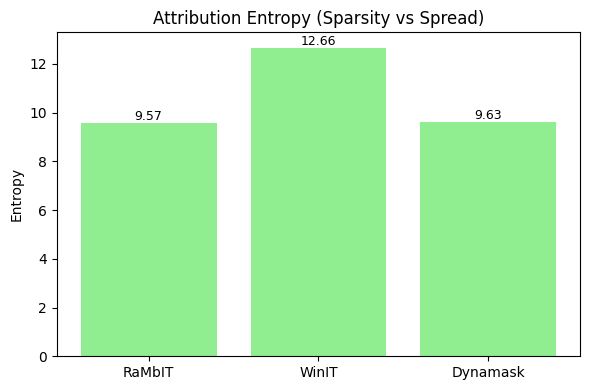

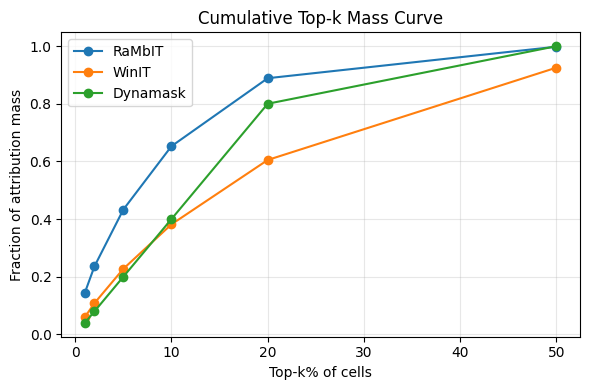

=== Results ===
RaMbIT     | Entropy=9.571 | k=1%:0.14, k=2%:0.24, k=5%:0.43, k=10%:0.65, k=20%:0.89, k=50%:1.00
WinIT      | Entropy=12.664 | k=1%:0.06, k=2%:0.11, k=5%:0.23, k=10%:0.38, k=20%:0.61, k=50%:0.93
Dynamask   | Entropy=9.627 | k=1%:0.04, k=2%:0.08, k=5%:0.20, k=10%:0.40, k=20%:0.80, k=50%:1.00


In [23]:
# -----------------------------
# Plot 1: Bar plot of entropy
# -----------------------------
names = list(results.keys())
entropies = [results[m]["entropy"] for m in names]

plt.figure(figsize=(6, 4))
bars = plt.bar(names, entropies, color="lightgreen")
for bar, val in zip(bars, entropies):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Entropy")
plt.title("Attribution Entropy (Sparsity vs Spread)")
plt.tight_layout()
plt.savefig("entropy_bar.png", dpi=300)
plt.show()

# -----------------------------
# Plot 2: Cumulative Top-k curves
# -----------------------------
plt.figure(figsize=(6, 4))
for name in results:
    plt.plot(ks, results[name]["cum_masses"], marker="o", label=name)
plt.xlabel("Top-k% of cells")
plt.ylabel("Fraction of attribution mass")
plt.title("Cumulative Top-k Mass Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("topk_curves.png", dpi=300)
plt.show()

# -----------------------------
# Print results
# -----------------------------
print("=== Results ===")
for m in results:
    cum_str = ", ".join([f"k={k}%:{v:.2f}" for k, v in zip(ks, results[m]["cum_masses"])])
    print(f"{m:10s} | Entropy={results[m]['entropy']:.3f} | {cum_str}")

# Temp debug to visualize masks

In [26]:
temp_probe_path = '/home/graph-winit/output/gru1layer/simulated_state/jimex/temp_probe.pkl'


with open(temp_probe_path, "rb") as f:
    temp_probe = pickle.load(f)

# temp_probe


In [31]:
# len(temp_probe['8_0_mask'])
temp_probe['8_0_mask'][0].shape

torch.Size([1, 1, 3, 200])

In [33]:
temp_probe['I_all'].shape

(32, 3, 200)

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure

def visualize_importance_with_masks(I_all, temp_probe, sample_indices=[0, 1], masks_per_cell=2):
    """
    Visualize importance maps with mask overlays.
    - Importance score plotted in grayscale
    - Up to `masks_per_cell` outlines overlaid per (t,d)
    """
    if hasattr(I_all, "detach"):  # torch tensor → numpy
        I_all = I_all.detach().cpu().numpy()
        
    N = len(sample_indices)
    fig, axes = plt.subplots(1, N, figsize=(6*N, 5), squeeze=False)
    axes = axes[0]  # flatten row
    
    for idx, sample_idx in enumerate(sample_indices):
        # extract importance map for sample
        imp = I_all[sample_idx]  # shape (D, T)

        ax = axes[idx]
        imshow = ax.imshow(imp, cmap="gray", aspect="auto")
        ax.set_title(f"Sample {sample_idx}", fontsize=14)

        # categorical y-axis for D
        ax.set_yticks([0,1,2])
        ax.set_yticklabels([0,1,2], fontsize=12)
        ax.set_ylabel("d", fontsize=13)
        ax.set_xlabel("t", fontsize=13)

        D, T = imp.shape
        for d in range(D):
            for t in range(T):
                key = f"{t}_{d}_mask"
                if key in temp_probe:
                    masks = temp_probe[key]
                    for m in range(min(masks_per_cell, len(masks))):
                        mask = masks[m].squeeze()
                        if hasattr(mask, "detach"):  
                            mask = mask.detach().cpu().numpy()
                        if mask.ndim == 3:  
                            mask = mask[0]

                        # find contours and draw them in softer red
                        contours = measure.find_contours(mask, 0.5)
                        for contour in contours:
                            ax.plot(
                                contour[:, 1], contour[:, 0], 
                                color=(1, 1, 0, 0.5),  # softer semi-transparent red
                                linewidth=1.2
                            )

    plt.tight_layout()
    plt.show()


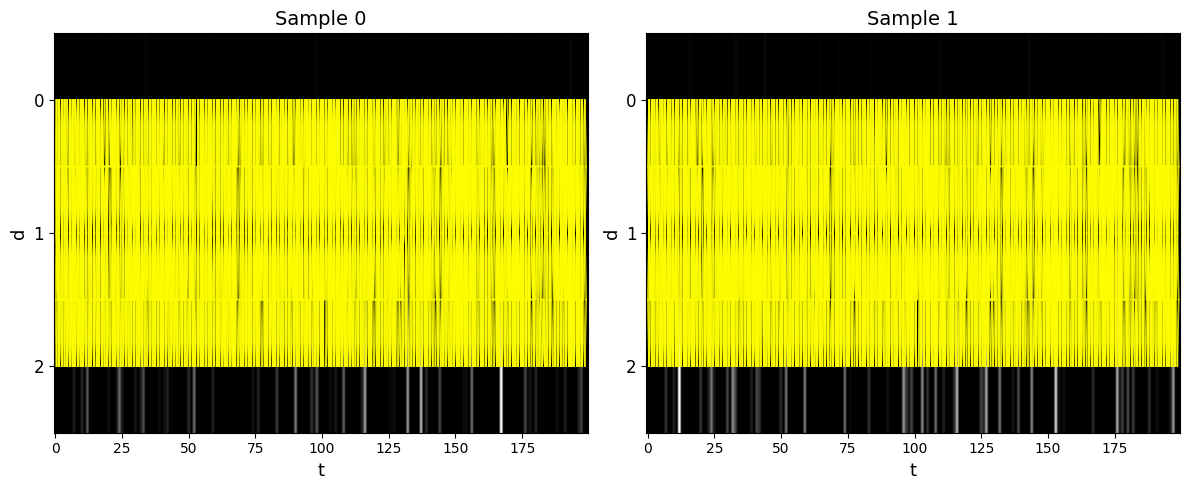

In [40]:
visualize_importance_with_masks(
    I_all=temp_probe['I_all'], 
    temp_probe=temp_probe, 
    sample_indices=[0, 1],   # which batch indices to plot
    masks_per_cell=2         # how many masks per cell to overlay
)